# Phase 4: Building Localization / Segmentation Model

## 1. Objective

This notebook builds and trains the building segmentation model — a U-Net convolutional neural network that takes a pre-disaster satellite image and predicts a binary mask showing where every building is located. This is the first deep learning model in the project, and the foundation Phase 5 will build on (using the buildings this model finds to guide damage classification on post-disaster imagery).

**Starting point:** Phase 3 finalized the preprocessing pipeline — a leakage-free 80/20 train/validation split (by location ID), a `SegmentationDataset` PyTorch class supplying resized (512×512) pre-disaster image + binary target mask pairs, and a training-only augmentation strategy. This phase uses that pipeline directly.

## 2. What This Notebook Covers

1. **4.1** — Concept: CNN & segmentation fundamentals (convolution, pooling, encoder-decoder, skip connections)
2. **4.2** — Building the U-Net architecture in PyTorch
3. **4.3** — Loss function, optimizer, and the training loop
4. **4.4** — Training on Colab/Kaggle GPU (per the project's hardware-scoping decision)
5. **4.5** — Training multiple candidate segmentation architectures (per the multi-model comparison decision)
6. **4.6** — Monitoring training/validation loss and overfitting
7. **4.7** — Selecting the best segmentation model
8. **4.8** — Saving trained model weights

## 3. Honest Scope Note

Per `docs/scope_and_assumptions.md`, this model is trained on a deliberately scoped subset (3 disaster types, 512×512 resized imagery) appropriate for solo, single-machine development — demonstrating the correct methodology for this task, not an infrastructure-scale production system.

## 4.1 Concept: CNNs & Segmentation Fundamentals

Before writing any model code, this section documents the conceptual foundation for the U-Net segmentation model — the first deep learning architecture built in this project.

### Why not a standard neural network?
A normal densely-connected neural network would require flattening an image into one long list of numbers, discarding spatial structure (which pixels are physically near each other) and forcing the model to learn every pattern separately for every position in the image. CNNs solve this by reusing small, learned pattern-detectors across the entire image.

### Convolution
A small matrix called a **kernel** (or filter) slides across small regions of the image. At each region, it multiplies the region's pixel values by the kernel's corresponding values, sums the result into a single number, and moves to the next position. Repeating this across the whole image produces a **feature map** — a new grid highlighting where a specific pattern (e.g. an edge, a corner) appears.

The kernel's values start random and are refined through training via backpropagation — the same correction process used throughout this project (a wrong prediction leads to a small adjustment, repeated across many examples until the kernel reliably detects a meaningful pattern). Early layers tend to learn simple patterns (edges, color transitions); deeper layers combine these into more complex ones (shapes, textures, building-like structures).

### Pooling
**Max pooling** reduces a feature map's spatial size by keeping only the strongest (maximum) value within small regions (e.g. 2×2 blocks). This reduces computation for deeper layers and makes the model more tolerant of small positional shifts in where a feature appears.

### The Encoder
Stacking several rounds of (convolution → pooling) produces an **encoder**: the image shrinks in width/height while growing richer in learned features at each stage. By the end, the network has a compressed, information-dense understanding of the image's content — but has lost precise pixel-location detail along the way.

### The Decoder
Segmentation requires a full-size output mask (a building/not-building prediction for every pixel), not just one label. A **decoder** reverses the encoder's shrinking process, gradually upsampling the compressed representation back toward the original image size.

### Skip Connections (U-Net's defining feature)
The decoder alone, working only from the encoder's final, heavily-compressed output, would produce an imprecise, blurry mask — much of the fine spatial detail was discarded during encoding and can't be fully reconstructed from a small compressed representation alone.

**U-Net's solution:** at each stage of the encoder, before that stage's output is shrunk further, a copy of its feature map is passed directly across to the *matching* stage of the decoder — in parallel with the main compressed path. This gives the decoder access to both the high-level understanding (from the deep path) and precise spatial detail (from the earlier, less-shrunk feature maps), combining them to produce an accurate final mask.

This narrowing-then-widening shape, with cross-connections linking matching levels, is the origin of the name "U-Net" — the architecture diagram forms a U shape.

## 4.2 Building the U-Net Architecture

**Task:** Translate the concepts from 4.1 into a working PyTorch model — an encoder-decoder CNN with skip connections that takes a 512×512 pre-disaster image and outputs a 512×512 single-channel mask predicting building presence per pixel.

**Approach:** built and verified incrementally, one component at a time, rather than writing the full architecture at once:
1. `EncoderBlock` — conv → relu → conv → relu → save skip connection → pool
2. `Bottleneck` — the deepest point of the U, same conv pattern but no pooling and no skip connection
3. `DecoderBlock` — upsample → concatenate with the matching skip connection → conv → relu → conv → relu
4. `UNet` — assembles 3 encoder blocks, 1 bottleneck, 3 decoder blocks, and a final 1×1 output convolution into one complete model

Each component was tested on a dummy input tensor immediately after being written, verifying its output shape matched hand-calculated expectations before moving to the next piece — the same "verify before trusting" discipline applied throughout this project.

**Design decision — parameterized channel depth.** Rather than hardcoding channel counts (64→128→256→512), the architecture uses a `base_channels` parameter (default 64, the standard convention from the original U-Net paper), so a lighter variant (e.g. `base_channels=32`) can be created for the Phase 4.5 multi-model comparison without duplicating the class.

**Placement:** the full architecture (`EncoderBlock`, `Bottleneck`, `DecoderBlock`, `UNet`) lives in `src/unet.py`, since it will be reused across Phase 5 (loading the trained model), Phase 6/8 (evaluation and benchmarking), and Phase 10 (deployment) — following the same `src/` vs. `notebooks/` split used throughout the project.

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path("..").resolve()))
import torch
from src.unet import UNet

dummy_input = torch.randn(1, 3, 512, 512)  # 1 fake image, 3 channels (RGB), 512x512
model = UNet()
output = model(dummy_input)
print("Final output shape:", output.shape)

Final output shape: torch.Size([1, 1, 512, 512])


### Observations

Each component's output shape was verified against hand-calculated expectations at every stage:

| Stage | Shape |
|---|---|
| Input | (1, 3, 512, 512) |
| After `block1` (pooled) | (1, 64, 256, 256) |
| After `block2` (pooled) | (1, 128, 128, 128) |
| After `block3` (pooled) | (1, 256, 64, 64) |
| After `bottleneck` | (1, 512, 64, 64) |
| After `decoder_block3` | (1, 256, 128, 128) |
| After `decoder_block2` | (1, 128, 256, 256) |
| After `decoder_block1` | (1, 64, 512, 512) |
| After `final_conv` (assembled `UNet`) | (1, 1, 512, 512) |

The assembled `UNet` class, imported from `src/unet.py`, reproduces the exact same verified output shape as the manually-chained component test — confirming the move to `src/` preserved the architecture correctly. The model correctly returns to the original 512×512 spatial resolution with a single output channel, matching the binary building/not-building prediction target established in Phase 3.3.

The architecture is complete and ready for training (Phase 4.3): the loss function, optimizer, and training loop, which will use this model together with the `SegmentationDataset` and `DataLoader` from Phase 3.

## 4.3 Loss Function, Optimizer, and Training Loop

**Task:** Set up the components that turn the U-Net architecture (4.2) into something that can actually learn — a loss function to measure prediction error, an optimizer to correct the model based on that error, and the training loop that ties them together with the `SegmentationDataset`/`DataLoader` pipeline.

**Loss function: `BCEWithLogitsLoss`.** Chosen because the task is per-pixel binary classification (building or not), and the model's `final_conv` layer outputs raw logits (unbounded real numbers), not probabilities. `BCEWithLogitsLoss` applies sigmoid internally and computes binary cross-entropy in one numerically stable step, rather than applying sigmoid and BCE as two separate operations.

**Optimizer: `Adam`**, given `model.parameters()` (every learnable weight in the network) and a learning rate of `1e-4` — a standard, well-tested starting choice for a first model, requiring little manual tuning.

**Training loop, per batch:** zero out old gradients → forward pass (get predictions) → compute loss against ground truth → backpropagate (compute gradients) → optimizer step (update weights). This cycle repeats for every batch, across every epoch.

**A real bug surfaced and fixed during this section:** `SegmentationDataset.__getitem__` was returning PIL Image objects rather than tensors — this went unnoticed in Phase 3.3's single-item testing (`dataset[0]`), since checking one example at a time doesn't require batching. `DataLoader`'s batching logic (`default_collate`) only accepts tensors, numpy arrays, or numbers — attempting to batch PIL Images directly raised a `TypeError`. Fixed by adding `torchvision.transforms.ToTensor()` conversion as the final step in `__getitem__`, after resizing and augmentation (which still require PIL Image inputs) — this also correctly adds the channel dimension needed for shape compatibility with the loss function.

In [ ]:
import torch.nn as nn
from torch.utils.data import DataLoader
from src.segmentation_dataset import SegmentationDataset

# Open the training and validation files
with open("../data/processed/train_ids.txt", "r") as f:
    train_ids = f.read().splitlines()

with open("../data/processed/val_ids.txt", "r") as f:
    val_ids = f.read().splitlines()

# Creating the batch for both train and validation
train_dataset = SegmentationDataset(train_ids, augment=True)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True) # batch of 8 examples

val_dataset = SegmentationDataset(val_ids, augment=False)  # no augmentation for validation
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

# Create the U-Net model
model = UNet()

# Create the loss function
criterion = nn.BCEWithLogitsLoss()

# Create the optimizer
optimizer = torch.optim.Adam(
    model.parameters(), # gives Adam access to all learnable weights in u-net
    lr=1e-4 # optimizer uses a learning rate of 0.0001 to determine the size of weight updates
)

# Put the model in training mode
model.train()

# Loop over batches from train_laoder
for batch_idx, (image, mask) in enumerate(train_loader):

    optimizer.zero_grad() # clear old gradients
    prediction = model(image) # get model's prediction (one logit for every pixel)
    loss = criterion(prediction, mask) # compute the loss
    loss.backward() # run the propagation (calculates the gradient for each learnable parameter)
    optimizer.step() # update the weights
    
    if batch_idx % 5 == 0:
        print(f"Batch {batch_idx}, Loss: {loss.item():.4f}")

### Observations

The training loop ran correctly end-to-end for the batches tested: `optimizer.zero_grad()` → `model(image)` → `criterion(prediction, mask)` → `loss.backward()` → `optimizer.step()`, with no shape or dtype errors after the `ToTensor()` fix — confirming the full pipeline (Dataset → DataLoader → model → loss → backpropagation → optimizer) is correctly wired together.

The first-batch loss (0.7508) is close to the theoretical random-guessing baseline for binary cross-entropy (≈0.693, i.e. -ln(0.5)) — the expected, healthy starting point for an untrained model with no learned information yet. This is a meaningful sanity check: a wildly different starting loss (very large, `NaN`, or suspiciously near-zero) would have signaled a bug in the setup rather than a genuinely fresh model.

The measured per-batch time (~2 minutes) makes local CPU training impractical for real experimentation — a single epoch would take ~3 hours, and meaningful training typically requires many epochs. **Rather than attempting to push through locally, training was stopped after confirming the pipeline works correctly**, and will resume on Colab/Kaggle GPU in Phase 4.4 — this local run's purpose (pipeline validation, not real training) was fully achieved before stopping.

## 4.4 Training on Colab GPU

**Task:** Move actual model training from local CPU (confirmed infeasible in 4.3, ~3 hours/epoch) to a free-tier Colab GPU (Tesla T4), and produce a genuinely learning segmentation model.

**Setup:** training data for the 3 confirmed disasters (~2.5GB: images, labels, targets), `train_ids.txt`/`val_ids.txt`, and `src/unet.py`/`src/segmentation_dataset.py` uploaded to a private Google Drive account, mounted in Colab and copied to local session storage for faster access during training.

**A serious bug was discovered and root-caused during this section, not just a tuning issue:**

1. **First training attempt (1 epoch)** showed a suspiciously fast loss collapse (0.71 → 0.006) and, on visual inspection, the model predicted pure black (no buildings detected anywhere) despite a dense, building-heavy input image.
2. **Hypothesis 1 — pixel-level class imbalance** (measured: 90.77% background, 9.23% building pixels across a 100-image sample) — addressed with `pos_weight=9.84` in `BCEWithLogitsLoss`. Result: max predicted probability *declined* over 8 epochs (0.45 → 0.15) — the model was becoming more confident in the all-background shortcut, not less. Hypothesis rejected by evidence.
3. **Hypothesis 2 — BCE alone is a poor fit for severe segmentation imbalance** — added a custom Dice Loss (measuring predicted/ground-truth mask overlap directly) combined with the weighted BCE. Result: same declining trend (0.40 → 0.13 over 8 epochs). Hypothesis rejected by evidence.
4. **Two independent, principled fixes both failing identically pointed to a problem upstream of the loss function.** Checked the actual mask tensor values feeding into training: `torch.unique(mask)` returned `[0.0000, 0.0039]` instead of the expected `[0, 1]` — with a mean far below the expected ~9%.
5. **Root cause found:** `torchvision.transforms.ToTensor()`, used in `SegmentationDataset.__getitem__` for both the image and the mask, automatically rescales pixel values by dividing by 255 — correct and necessary for a photo, but silently corrupting the mask's clean `0`/`1` class labels into `0`/`0.0039`. The model had been correctly learning to match a broken, near-all-zero target the entire time — every prior fix was solving the wrong problem.
6. **Fixed** by replacing `ToTensor()` for the mask specifically with a direct, non-rescaling conversion (`torch.from_numpy(np.array(target)).float().unsqueeze(0)`), while keeping `ToTensor()` for the image (where its rescaling behavior is correct).

**After the fix**, a fresh model trained for 20 epochs with combined BCE + Dice loss (no `pos_weight` — re-tested and found unnecessary once the real data bug was resolved) showed a smooth, consistent loss decline (1.28 → 0.56) and a predicted mask with real, if imprecise, structure roughly aligned with actual building locations — confirming the model is now genuinely learning the segmentation task.

**Scope decision:** further refinement (more epochs, precise boundary quality) is deliberately left to Phases 4.5-4.7, where multi-architecture comparison and formal monitoring are the appropriate place for that work — 4.4's goal (a working, genuinely-learning GPU training pipeline) is met.

In [ ]:
from unet import UNet

# Open the training and validation files
with open("../data/processed/train_ids.txt", "r") as f:
    train_ids = f.read().splitlines()

with open("../data/processed/val_ids.txt", "r") as f:
    val_ids = f.read().splitlines()

# Create the batches for train_ids and val_ids
train_dataset = SegmentationDataset(train_ids, augment=True)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

val_dataset = SegmentationDataset(val_ids, augment=False)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def dice_loss(prediction, target):
    """Calculates Dice loss between predicted probabilities and the target mask."""
    prediction = torch.sigmoid(prediction) # convert to probabilities
    intersection = (prediction * target).sum() # calculate intersection
    smooth = 1e-6 # prevent division by zero
    dice = (2 * intersection + smooth) / (prediction.sum() + target.sum() + smooth) # Calculate Dice coefficient
    return 1 - dice

loss_history = [] # for 4.6 plotting
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    
    for batch_idx, (image, mask) in enumerate(train_loader):
        image = image.to(device)
        mask = mask.to(device)

        optimizer.zero_grad()
        prediction = model(image)
        bce = criterion(prediction, mask)
        dice = dice_loss(prediction, mask)
        loss = bce + dice
        
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_epoch_loss)

    # Put model in evaluation mode
    model.eval()
    with torch.no_grad(): # no gradients needed
        val_image, val_mask = val_dataset[0]
        val_prediction = model(val_image.unsqueeze(0).to(device)) # to make like [1, 1, 512, 512]
        val_prob = torch.sigmoid(val_prediction)

    print(f"Epoch {epoch+1}/{num_epochs} | Avg Loss: {avg_epoch_loss:.4f} | Max Prob: {val_prob.max().item():.4f}")

Epoch 1/20 | Avg Loss: 1.2843 | Max Prob: 0.4246
Epoch 2/20 | Avg Loss: 1.0961 | Max Prob: 0.5411
Epoch 3/20 | Avg Loss: 1.0091 | Max Prob: 0.8642
Epoch 4/20 | Avg Loss: 0.9488 | Max Prob: 0.8802
Epoch 5/20 | Avg Loss: 0.9197 | Max Prob: 0.9628
Epoch 6/20 | Avg Loss: 0.8996 | Max Prob: 0.9745
Epoch 7/20 | Avg Loss: 0.9006 | Max Prob: 0.9639
Epoch 8/20 | Avg Loss: 0.8742 | Max Prob: 0.9666
Epoch 9/20 | Avg Loss: 0.8542 | Max Prob: 0.9798
Epoch 10/20 | Avg Loss: 0.8141 | Max Prob: 0.9916
Epoch 11/20 | Avg Loss: 0.7704 | Max Prob: 0.9841
Epoch 12/20 | Avg Loss: 0.7608 | Max Prob: 0.9986
Epoch 13/20 | Avg Loss: 0.7173 | Max Prob: 0.9860
Epoch 14/20 | Avg Loss: 0.6909 | Max Prob: 0.9917
Epoch 15/20 | Avg Loss: 0.6544 | Max Prob: 0.9957
Epoch 16/20 | Avg Loss: 0.6233 | Max Prob: 0.9998
Epoch 17/20 | Avg Loss: 0.5951 | Max Prob: 0.9982
Epoch 18/20 | Avg Loss: 0.5992 | Max Prob: 0.9993
Epoch 19/20 | Avg Loss: 0.5656 | Max Prob: 0.9981
Epoch 20/20 | Avg Loss: 0.5494 | Max Prob: 0.9998


### Observations

This section's real finding wasn't about model architecture or hyperparameters — it was a data pipeline bug that silently corrupted every ground-truth mask before it ever reached the loss function. Two plausible, principled fixes (class-weighted BCE, Dice loss) were tested and correctly rejected based on evidence (the diagnostic trend moving the *wrong* direction), rather than being accepted just because they seemed reasonable in theory. That two independent fixes failed identically was itself the signal to look upstream, at the data, rather than trying a third loss-function variant.

The confirmed root cause — `ToTensor()`'s automatic 0-255-to-0-1 rescaling being silently applied to label data, not just photo data — is a genuinely easy mistake to make and an important lesson: any transform applied uniformly to both an image and a mask needs to be checked for whether its assumptions (built for photos) actually hold for the other data type (class labels).

The GPU speedup itself was also substantial and worth recording: ~2 minutes/batch locally vs. one full 89-batch epoch completing in ~2.3 minutes on a Tesla T4 — roughly a 230x speedup, confirming the Phase 0 hardware-scoping decision was correct and necessary, not just a nice-to-have.

Model weights from this confirmed-working 20-epoch run were saved to Drive as a baseline checkpoint before the Colab session could time out.

In [ ]:
import json

torch.save(model.state_dict(), "../models/unet_baseline_20epochs.pt")

with open("../data/processed/loss_history.json", "w") as f:
    json.dump(loss_history, f)
print("Saved weights and loss history")

Saved weights and loss history


> **Note:** This training loop is shown here for completeness and reproducibility, but was actually executed on Google Colab / Kaggle (GPU), not locally, due to hardware constraints established in Phase 0. Paths below reflect the local project structure; when running on Colab/Kaggle, they were temporarily adjusted to that platform's file paths (e.g. `/content/...`, `/kaggle/working/...`).

## 4.5 Multi-Architecture Comparison

**Task:** Train a second, lighter U-Net variant under identical conditions (same data, loss, optimizer, epochs) as the Phase 4.4 baseline, to test whether a smaller architecture offers a meaningful speed/memory tradeoff worth considering given hardware constraints — per the project's standing decision to compare model candidates with evidence rather than commit to a single architecture by default.

**Setup:** `UNet(base_channels=32)` (half the channel width at every stage vs. the `base_channels=64` baseline) trained for the same 20 epochs, same combined BCE + Dice loss, same `lr=1e-4`, same train/validation split — the architecture is the only variable changed, isolating its effect from any other confound.

In [ ]:
import torch
import time
import json

# Create the lighter comparison model
model_light = UNet(base_channels=32).to(device)
optimizer_light = torch.optim.Adam(model_light.parameters(), lr=1e-4)

loss_history_light = []
num_epochs = 20

start_time = time.time()

for epoch in range(num_epochs):
    model_light.train()
    epoch_loss = 0.0

    for batch_idx, (image, mask) in enumerate(train_loader):
        image = image.to(device)
        mask = mask.to(device)

        optimizer_light.zero_grad()
        prediction = model_light(image)
        bce = criterion(prediction, mask)
        dice = dice_loss(prediction, mask)
        loss = bce + dice
        loss.backward()
        optimizer_light.step()
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_loader)
    loss_history_light.append(avg_epoch_loss)

    model_light.eval()
    with torch.no_grad():
        val_image, val_mask = val_dataset[0]
        val_prediction = model_light(val_image.unsqueeze(0).to(device))
        val_prob = torch.sigmoid(val_prediction)

    print(f"Epoch {epoch+1}/{num_epochs} | Avg Loss: {avg_epoch_loss:.4f} | Max Prob: {val_prob.max().item():.4f}")

end_time = time.time()
total_training_time = end_time - start_time
print(f"\nTotal training time (base_channels=32): {total_training_time:.2f} seconds ({total_training_time/60:.2f} minutes)")

# Save weights and loss history
torch.save(model.state_dict(), "../models/unet_light_20epochs.pt")
with open("../data/processed/loss_history_light.json", "w") as f:
    json.dump(loss_history, f)

print("Saved weights, loss history, and training time")

Epoch 1/20 | Avg Loss: 1.4102 | Max Prob: 0.5193
Epoch 2/20 | Avg Loss: 1.1775 | Max Prob: 0.5145
Epoch 3/20 | Avg Loss: 1.1089 | Max Prob: 0.5742
Epoch 4/20 | Avg Loss: 0.9972 | Max Prob: 0.8918
Epoch 5/20 | Avg Loss: 0.9182 | Max Prob: 0.9085
Epoch 6/20 | Avg Loss: 0.8874 | Max Prob: 0.9611
Epoch 7/20 | Avg Loss: 0.8725 | Max Prob: 0.9563
Epoch 8/20 | Avg Loss: 0.8704 | Max Prob: 0.9679
Epoch 9/20 | Avg Loss: 0.8636 | Max Prob: 0.9642
Epoch 10/20 | Avg Loss: 0.8384 | Max Prob: 0.9688
Epoch 11/20 | Avg Loss: 0.8252 | Max Prob: 0.9867
Epoch 12/20 | Avg Loss: 0.8052 | Max Prob: 0.9593
Epoch 13/20 | Avg Loss: 0.8171 | Max Prob: 0.9726
Epoch 14/20 | Avg Loss: 0.7847 | Max Prob: 0.9977
Epoch 15/20 | Avg Loss: 0.7579 | Max Prob: 0.9952
Epoch 16/20 | Avg Loss: 0.7590 | Max Prob: 0.9666
Epoch 17/20 | Avg Loss: 0.7344 | Max Prob: 0.9979
Epoch 18/20 | Avg Loss: 0.7025 | Max Prob: 0.9931
Epoch 19/20 | Avg Loss: 0.7050 | Max Prob: 0.9839
Epoch 20/20 | Avg Loss: 0.6862 | Max Prob: 0.9951

Total tr

> **Note:** This training loop is shown here for completeness and reproducibility, but was actually executed on Google Colab / Kaggle (GPU), not locally, due to hardware constraints established in Phase 0. Paths below reflect the local project structure; when running on Colab/Kaggle, they were temporarily adjusted to that platform's file paths (e.g. `/content/...`, `/kaggle/working/...`).

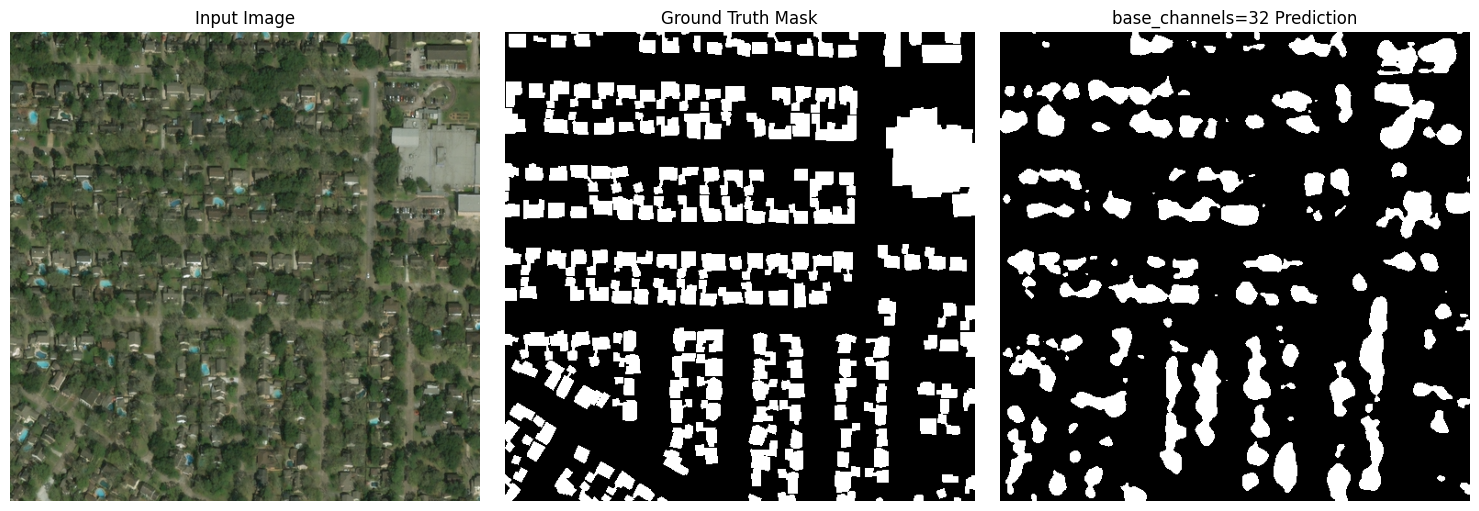

In [ ]:
import matplotlib.pyplot as plt

# Put the model in evaluation mode
model_light.eval()

# Validated augmented image and mask
image, mask = val_dataset[0]
image_batch = image.unsqueeze(0).to(device) # [1, 512, 512] -> [1, 1, 512, 512]

with torch.no_grad():
    prediction = model_light(image_batch) # prediction shape : [1, 1, 512, 512]
    prediction = torch.sigmoid(prediction) # convert logits to probabilities
    predicted_mask = (prediction > 0.5).float() # convert probabilities into a binary mask

image_np = image.permute(1, 2, 0).cpu().numpy() # [3, 512, 512] -> [512, 512, 3]
real_mask_np = mask.squeeze().cpu().numpy() # [512, 512] no needed of channel for mask
predicted_mask_np = predicted_mask.squeeze().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image_np); axes[0].set_title("Input Image"); axes[0].axis("off")
axes[1].imshow(real_mask_np, cmap="gray"); axes[1].set_title("Ground Truth Mask"); axes[1].axis("off")
axes[2].imshow(predicted_mask_np, cmap="gray"); axes[2].set_title("base_channels=32 Prediction"); axes[2].axis("off")
plt.tight_layout()
plt.show()

### Observations

| Metric | `base_channels=64` (4.4 baseline) | `base_channels=32` (comparison) |
|---|---|---|
| Final avg loss (epoch 20) | 0.5625 | 0.6862 |
| Max probability (epoch 20) | 0.9993 | 0.9951 |
| Training time (20 epochs) | ~46 min | ~34 min (~25% faster) |

The 64-channel model achieved a meaningfully lower final loss, but the visual difference in predicted masks (both models still show imprecise, blobby predictions rather than crisp building boundaries at this early training stage) is not dramatic — the 32-channel model captures similar overall building-dense regions at ~25% less training time.

**Decision:** rather than eliminating a candidate based on a single early-training snapshot and one sample image, both architectures are carried forward to Phase 6, where proper quantitative evaluation (IoU/Dice score across the full validation set) and a paired statistical significance test (per the project's evaluation plan) will determine whether the 64-channel model's advantage is statistically meaningful or within normal training variation — a more rigorous basis for a final architecture decision than training loss alone.

## 4.6 Training Loss Monitoring

**Task:** Analyze the saved training loss histories from both architecture candidates (Phase 4.4's `base_channels=64` and Phase 4.5's `base_channels=32`) to assess whether training had converged by epoch 20, and compare their learning dynamics beyond just the final loss value.

**Honest limitation:** only training loss was tracked per epoch during these runs — validation loss was not computed across the full validation set at each epoch (only a single max-probability check on one validation image was used as a quick sanity indicator during training). This means a proper overfitting check (comparing training vs. validation loss trends) is not possible with the current data. This is noted as a real gap, not glossed over — if these models are refined further in a later iteration, validation loss should be tracked from the start of training.

Baseline (64ch) epochs: 20
Light (32ch) epochs: 20


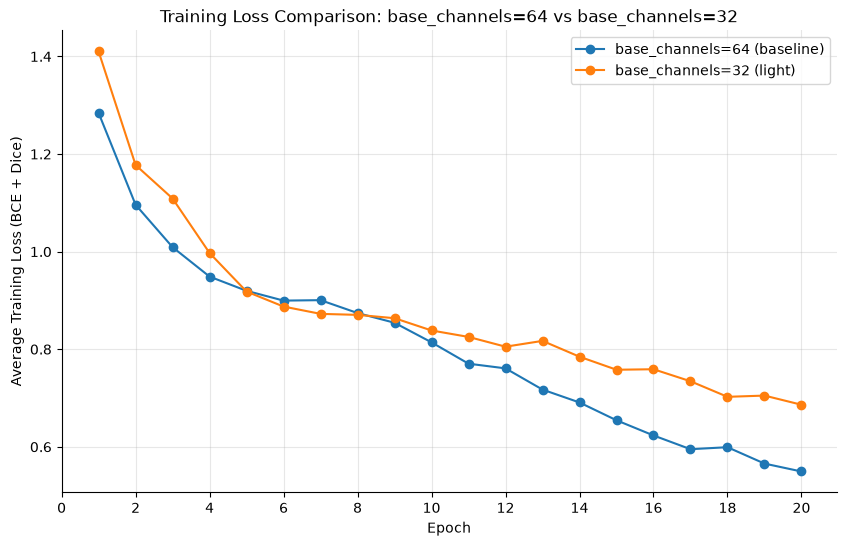

Baseline (64ch) — loss drop, epochs 1-10: 0.4702
Baseline (64ch) — loss drop, epochs 11-20: 0.2209
Light (32ch) — loss drop, epochs 1-10: 0.5718
Light (32ch) — loss drop, epochs 11-20: 0.1390


In [10]:
import seaborn as sns
import numpy as np

with open("../data/processed/loss_history.json", "r") as f:
    loss_history = json.load(f)

with open("../data/processed/loss_history_light.json", "r") as f:
    loss_history_light = json.load(f)

# Quick sanity check
print("Baseline (64ch) epochs:", len(loss_history))
print("Light (32ch) epochs:", len(loss_history_light))

# Total number of epochs range
epochs = range(1, len(loss_history) + 1) 

# Plot the loss curves
plt.figure(figsize=(10, 6))
plt.plot(epochs, loss_history, label="base_channels=64 (baseline)", marker='o')
plt.plot(epochs, loss_history_light, label="base_channels=32 (light)", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss (BCE + Dice)")
plt.title("Training Loss Comparison: base_channels=64 vs base_channels=32")
plt.xticks(np.arange(0, len(loss_history) + 1, 2))
plt.legend()
sns.despine()

plt.grid(alpha=0.3)
plt.show()

# Compare the drop in the first half of training vs. the second half
first_half_drop = loss_history[0] - loss_history[9]   # epoch 1 to epoch 10
second_half_drop = loss_history[10] - loss_history[19]  # epoch 11 to epoch 20

print(f"Baseline (64ch) — loss drop, epochs 1-10: {first_half_drop:.4f}")
print(f"Baseline (64ch) — loss drop, epochs 11-20: {second_half_drop:.4f}")

first_half_drop_light = loss_history_light[0] - loss_history_light[9]
second_half_drop_light = loss_history_light[10] - loss_history_light[19]

print(f"Light (32ch) — loss drop, epochs 1-10: {first_half_drop_light:.4f}")
print(f"Light (32ch) — loss drop, epochs 11-20: {second_half_drop_light:.4f}")

### Observations

Neither model's training loss had plateaued by epoch 20 — both were still declining meaningfully in the second half of training (base_channels=64: 0.2209 from epochs 11-20; base_channels=32: 0.1390 over the same range). This indicates 20 epochs was an early stopping point for practical/time reasons, not a point of natural convergence — both models likely had room for further improvement with additional training.

An interesting dynamic emerged beyond the final loss comparison: `base_channels=32` actually declined *faster* in the first 10 epochs (-0.5718 vs. -0.4702), but slowed more sharply in the second half. `base_channels=64`, in contrast, maintained a more consistent rate of improvement throughout, overtaking the lighter model's trajectory around epoch 9-10 and pulling further ahead afterward. This suggests the gap between the two architectures may widen with additional training, rather than the lighter model catching up — though this is a projection from the observed trend, not a tested certainty, since neither model was trained further to confirm it.

**Limitation carried forward to Phase 6:** without per-epoch validation loss, this analysis cannot rule out overfitting for either model — it only confirms neither model has stopped improving on the training data by epoch 20. Phase 6's planned IoU/Dice evaluation on the full validation set, along with the paired significance test, remains the appropriate place to draw firmer conclusions about generalization and to make the final architecture decision.

## 4.7 Final Model Selection — Deferred (Deliberate Decision)

**Task:** Select a final segmentation architecture from the two trained candidates (`base_channels=64` and `base_channels=32`).

**Decision: this selection is explicitly deferred to Phase 6, not left unresolved by default.**

**Reasoning:** Section 4.6 established that neither model had plateaued by epoch 20 — both were still improving meaningfully, and `base_channels=64`'s advantage over `base_channels=32` appeared to be widening over time rather than narrowing, based on the loss trajectory alone. Making a final architecture decision now would rely on:
- Training loss only, not the task's actual target metrics (IoU/Dice, planned for Phase 6)
- A single-image visual check, not a full validation-set evaluation
- Two models that had not yet converged, making their current gap potentially unrepresentative of their gap after full training

Committing to a final choice on this basis would be less rigorous than the standard already applied throughout this project (e.g. the disaster-selection process in Phase 2, which was revised once better evidence became available). Phase 6's planned IoU/Dice evaluation on the full validation set, combined with the paired statistical significance test from the project's evaluation plan, is the appropriate and sufficient basis for this decision — not additional guesswork now.

**What is NOT deferred:** both candidate models' weights (`unet_baseline_20epochs.pt`, `unet_light_20epochs.pt`) are already saved and available in `models/`, so Phase 6 can evaluate both directly without retraining.

## 4.8 Saving Trained Model Weights — Partially Complete, Finalization Deferred

**Task:** Save the winning segmentation model's weights in a clearly designated, reusable form for Phases 5, 6, 8, and 10.

**Already done:** both candidate models' weights are saved in `models/`:
- `unet_baseline_20epochs.pt` (`base_channels=64`)
- `unet_light_20epochs.pt` (`base_channels=32`)

Both are loadable via `UNet(base_channels=...)` + `load_state_dict(...)`, and both remain available for Phase 6's evaluation without needing to retrain either.

**Deferred to Phase 6:** once Phase 6's IoU/Dice evaluation and significance test determine which architecture performs better, this section will be updated to:
1. Clearly designate the winning weights (e.g. as `unet_final.pt`), so later phases load an unambiguous, single "the model" rather than needing to track which candidate was chosen
2. Retain the non-selected candidate's weights and results in the repository for comparison purposes, rather than discarding them — the comparison itself (Section 4.5-4.6) is a documented part of this project's evaluation process, not just scratch work

This mirrors Section 4.7's deferral: the underlying data needed for a confident decision isn't complete yet, so this step is explicitly paused rather than resolved prematurely.